In [93]:
import numpy as np
import scipy.stats as stats
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

In [94]:
metadata = pd.read_csv("../file_metadata.csv")

In [95]:
gender = metadata[metadata['folder'] == "gender_names"]

female = gender[gender['sub_categories'] == "female"]
male = gender[gender['sub_categories'] == "male"]

regional = metadata[metadata['folder'] == "person"]

arabic = regional[regional['sub_categories'] == "arabic"]
american = regional[regional['sub_categories'] == "american"]
african = regional[regional['sub_categories'] == "african"]
european = regional[regional['sub_categories'] == "european"]
indian = regional[regional['sub_categories'] == "indian"]

In [96]:
def read_indiv_results(metadata,model,chosen_datasets):
   df = pd.DataFrame()

   chosen = chosen_datasets[chosen_datasets['model'] == model]

   for i in range(len(chosen)):
      path = chosen['path'].iloc[i]
      path = path.replace("\\","/")
      file_name = path.split("/")[-1].split(".")[0]+".csv"
      split_path = path.split("/")
      path = f"../indiv_evaluations/{split_path[-3]}/{split_path[-2]}/evaluated_{file_name}"

      if df.empty:
         df = pd.read_csv(path)
      else:
         df = pd.concat([df, pd.read_csv(path)])

   df['prec'] = np.where(
      df['tp']+df['fp'] == 0, 0.0, df['tp']/(df['tp']+df['fp'])) 
   df['rec'] = np.where(
      df['tp']+df['fn'] == 0, 0.0, df['tp']/(df['tp']+df['fn']))
   df['f1'] = np.where(
      df['prec']+df['rec'] == 0.0, 0.0, 2 * (df['prec'] * df['rec']) / (df['prec'] + df['rec'])) 

   df['l_prec'] = np.where(
      df['precision_loose_tp'] + df['precision_loose_fp'] == 0, 0.0, df['precision_loose_tp']/(df['precision_loose_tp']+df['precision_loose_fp'])) 
   df['l_rec'] = np.where(
      df['recall_loose_tp']+df['recall_loose_fn'] == 0, 0.0, df['recall_loose_tp']/(df['recall_loose_tp']+df['recall_loose_fn']))
   df['l_f1'] = np.where(
      df['l_prec']+df['l_rec'] == 0.0, 0.0, df['recall_loose_tp']/(df['recall_loose_tp']+df['recall_loose_fn']))
      
   df['ul_prec'] = np.where(
      df['tp_ul']+df['fp_ul'] == 0, 0.0, df['tp_ul']/(df['tp_ul']+df['fp_ul']))
   df['ul_rec'] = np.where(
      df['tp_ul']+df['fn_ul'] == 0, 0.0, df['tp_ul']/(df['tp_ul']+df['fn_ul']))
   df['ul_f1'] = np.where(
      df['ul_prec']+df['ul_rec'] == 0.0, 0.0, 2 * (df['ul_prec'] * df['ul_rec']) / (df['ul_prec'] + df['ul_rec']))

   return df

In [97]:
male_results_mono = read_indiv_results(metadata, 'mono', male)
male_results_multi = read_indiv_results(metadata, 'multi', male)
female_results_mono = read_indiv_results(metadata, 'mono', female)
female_results_multi = read_indiv_results(metadata, 'multi', female)

arabic_results_mono = read_indiv_results(metadata, 'mono', arabic)
arabic_results_multi = read_indiv_results(metadata, 'multi', arabic)
american_results_mono = read_indiv_results(metadata, 'mono', american)
american_results_multi = read_indiv_results(metadata, 'multi', american)
african_results_mono = read_indiv_results(metadata, 'mono', african)
african_results_multi = read_indiv_results(metadata, 'multi', african)
european_results_mono = read_indiv_results(metadata, 'mono', european)
european_results_multi = read_indiv_results(metadata, 'multi', european)
indian_results_mono = read_indiv_results(metadata, 'mono', indian)
indian_results_multi = read_indiv_results(metadata, 'multi', indian)

In [100]:
model = "multi"
measure = "f1"

masc_names = (male_results_mono if model == "mono" else male_results_multi)[measure].to_list()
fem_names = (female_results_mono if model == "mono" else female_results_multi)[measure].to_list()

arabic_names = (arabic_results_mono if model == "mono" else arabic_results_multi)[measure].to_list()
american_names = (american_results_mono if model == "mono" else american_results_multi)[measure].to_list()
african_names = (african_results_mono if model == "mono" else african_results_multi)[measure].to_list()
european_names = (european_results_mono if model == "mono" else european_results_multi)[measure].to_list()
indian_names = (indian_results_mono if model == "mono" else indian_results_multi)[measure].to_list()

In [101]:
stat, p_value = stats.wilcoxon(masc_names, fem_names, alternative='two-sided')

print(f"Between {'a'} and {'b'} for the {model} model")
print(f"U-statistic: {stat}, p-value: {p_value} with the {measure} measure")

Between a and b for the multi model
U-statistic: 20996.0, p-value: 0.00045203090298711197 with the f1 measure


In [106]:
comparison_1 = pd.DataFrame(data={
    "arabic_names": arabic_names, 
    "american_names": american_names, 
    "african_names": african_names, 
    "european_names": european_names, 
    "indian_names": indian_names, 
    # "typos_per": typos_per, 
})

comparison_2 = pd.DataFrame(data={
    "fem_names": fem_names, 
    "masc_names": masc_names, 
    # "random_per": random_per, 
})

dictionary_map = {
    "arabic_names": "arabic", 
    "american_names": "american", 
    "african_names": "african", 
    "european_names": "european", 
    "indian_names": "indian", 
    "typos_per": "typos", 
    "fem_names": "feminine", 
    "masc_names": "masculine", 
    "random_per": "random", 
}

chosen_comparison = comparison_1

conf_mat = pd.DataFrame(columns=chosen_comparison.columns,index=chosen_comparison.columns)
for col in conf_mat.columns:
    for row in conf_mat.columns:
        stat, p_value = stats.wilcoxon(globals()[col], globals()[row], alternative='two-sided')
        if col == row:
            conf_mat.loc[row,col] = np.nan
            continue
        conf_mat.loc[row,col] = p_value
conf_mat = conf_mat.astype(float)

/opt/anaconda3/envs/ml/lib/python3.13/site-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


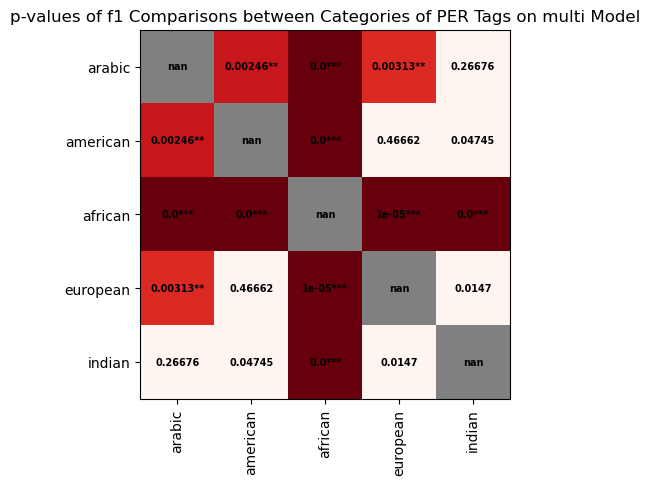

In [109]:
bonferri_correction = 0.05/(np.pow(len(conf_mat.columns),2)/2 - len(conf_mat.columns)/2)
cmap = matplotlib.colormaps['Reds'].reversed()

norm = matplotlib.colors.Normalize(vmin=0, vmax=bonferri_correction*2, clip=True)

# ax.pcolormesh(x, y, Z, vmin=0, vmax=bonferri_correction*2, cmap='Reds')
cmap.set_bad('gray',1.)

fig, ax = plt.subplots()
im = ax.imshow(conf_mat,cmap=cmap,norm=norm)

ax.set_title(f"p-values of {measure} Comparisons between Categories of PER Tags on {model} Model")

masked_array = np.ma.array (conf_mat, mask=np.isnan(conf_mat))

# Displaying a color bar to understand
# which color represents which range of data
# plt.colorbar()

# Assigning labels of x-axis 
# according to dataframe
ax.set_xticks(range(len(conf_mat)), conf_mat.columns.to_series().replace(dictionary_map), rotation=90)

# Assigning labels of y-axis 
# according to dataframe
ax.set_yticks(range(len(conf_mat)), conf_mat.index.to_series().replace(dictionary_map))


for i, col in enumerate(conf_mat.columns):
    for j, row in enumerate(conf_mat.index):
        if conf_mat.loc[col, row] == 0:
            value = np.nan
        else:
            value = round(conf_mat.loc[col, row],5)
            if value < bonferri_correction*2:
                if value < bonferri_correction:
                    if value < bonferri_correction/5:
                        asterisks = "***"
                    else:
                        asterisks = "**"
                else:
                    asterisks = "*"
            else:
                asterisks = ""
            value = str(value) + asterisks
        text = ax.text(j, i, value,
                       ha="center", va="center", color="black",size=7,fontweight="bold")

# Displaying the figure
plt.show()